# 04 · Acuerdo entre evaluadores en OASIS

**OASIS** (*Open Affective Standardized Image Set*; Kurdi, Lozano y Banaji, 2017, *Behavior Research Methods*) contiene 900 imágenes de cuatro categorías (Animal, Object, Person, Scene), evaluadas en una escala de 1 a 7:
- **Valencia**: 1 = muy negativa, 4 = neutral, 7 = muy positiva.
- **Arousal** (activación): 1 = muy baja, 7 = muy alta.

OASIS **no reporta emociones discretas** (felicidad, miedo, etc.), sino estas dos dimensiones afectivas. Cada uno de los 822 participantes evaluó 225 imágenes (una de 4 listas) en **una sola** dimensión, así que cada imagen tiene unas 100 evaluaciones de valencia y otras 100 de arousal, de personas distintas.

**Preguntas**
1. ¿Qué tan confiable es el **promedio** por imagen (la norma que publica OASIS)?
2. ¿Cuánto coincide **una persona** con el consenso?
3. Al llevar la valencia a **3 clases** (Negative / Neutral / Positive, como en el clasificador de anuncios), ¿cuánto acuerdo hay y qué rendimiento máximo cabe esperar si las etiquetas vienen de un solo anotador?
4. ¿El acuerdo cambia según la categoría de imagen, el nivel de valencia o el género del evaluador?

**Medidas**
- **Split-half con corrección de Spearman-Brown**: confiabilidad del promedio (replica el análisis del artículo original).
- **ICC(1) e ICC(1,k)**, modelo de un factor (cada imagen la evalúan personas distintas): confiabilidad de un evaluador y del promedio de k evaluadores.
- **α de Krippendorff** (intervalar, ordinal y nominal): admite datos faltantes y un número distinto de evaluadores por imagen. Se reporta con IC95% bootstrap sobre imágenes.
- **Un evaluador vs. consenso de los demás** (*leave-one-out*): correlación en la escala 1–7 y, en 3 clases, accuracy, macro-F1 y κ de Cohen.

## 0. Configuración del entorno (Google Colab + Google Drive)
`OASIS_data_long.csv` pesa 134 MB y supera el límite de 100 MB de GitHub, por eso el repositorio solo contiene `oasis/Data files/OASIS_data_long.zip` (10 MB). En Colab, la celda siguiente:
1. clona el repositorio (o lo actualiza con `git pull` si ya existe);
2. monta Google Drive;
3. la primera vez, copia la carpeta `oasis/` del repositorio a `MyDrive/publicity_analysis/oasis/` y **descomprime ahí** `OASIS_data_long.csv`;
4. define `OASIS_DIR` (datos) y `OUT` (resultados) en Drive. A partir de aquí, todos los datos se leen **solo desde Drive**.

Fuera de Colab se usa la carpeta local `oasis/`.

In [3]:
import os
import shutil
import zipfile

REPO = 'publicity_analysis'
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists(f'/content/{REPO}'):
        !git clone https://github.com/mlacarrasco/{REPO}.git /content/{REPO}
    else:
        !git -C /content/{REPO} pull
    os.chdir(f'/content/{REPO}')

    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/publicity_analysis'
    OASIS_DIR = os.path.join(DRIVE_ROOT, 'oasis')
    OUT = os.path.join(DRIVE_ROOT, 'resultados', 'oasis')

    # Primera vez: copia los datos del repositorio a Drive (sin el OASIS.zip redundante)
    if not os.path.exists(os.path.join(OASIS_DIR, 'Data files', 'OASIS_data.csv')):
        print('Copiando oasis/ a', OASIS_DIR, '(solo la primera vez; puede tardar unos minutos)')
        shutil.copytree(f'/content/{REPO}/oasis', OASIS_DIR, dirs_exist_ok=True,
                        ignore=shutil.ignore_patterns('OASIS.zip', '.DS_Store'))
else:
    OASIS_DIR = 'oasis'
    OUT = os.path.join('resultados', 'oasis')

# Descomprime OASIS_data_long.csv junto al .zip (en Drive, si se está en Colab)
long_dir = os.path.join(OASIS_DIR, 'Data files')
if not os.path.exists(os.path.join(long_dir, 'OASIS_data_long.csv')):
    with zipfile.ZipFile(os.path.join(long_dir, 'OASIS_data_long.zip')) as z:
        z.extractall(long_dir)
    print('Descomprimido:', os.path.join(long_dir, 'OASIS_data_long.csv'))
print('Datos en:', OASIS_DIR, '| resultados en:', OUT)

Already up to date.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando oasis/ a /content/drive/MyDrive/publicity_analysis/oasis (solo la primera vez; puede tardar unos minutos)


FileNotFoundError: [Errno 2] No such file or directory: '/content/publicity_analysis/oasis'

In [2]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
from sklearn.metrics import cohen_kappa_score, confusion_matrix, f1_score

pd.set_option('display.float_format', '{:.3f}'.format)

# OASIS_DIR y OUT vienen de la celda de configuración (Google Drive en Colab)
DATA_CSV = os.path.join(OASIS_DIR, 'Data files', 'OASIS_data.csv')       # evaluaciones individuales
LONG_CSV = os.path.join(OASIS_DIR, 'Data files', 'OASIS_data_long.csv')  # mismas evaluaciones, formato largo
NORMS_CSV = os.path.join(OASIS_DIR, 'Stimulus set', 'OASIS', 'OASIS.csv')  # normas publicadas
IMG_DIR = os.path.join(OASIS_DIR, 'Stimulus set', 'OASIS', 'images')
os.makedirs(OUT, exist_ok=True)

DIMS = ['Valence', 'Arousal']
LEVELS = np.arange(1, 8)
CLASSES = ['Negative', 'Neutral', 'Positive']
N_BOOT = 1000
rng = np.random.default_rng(0)

In [3]:
!pwd

/Users/miguelcarrascoudp/Documents/GitHub/publicity_analysis


## 1. Datos
Los CSV vienen con saltos de línea antiguos de Mac (`\r`) y codificación latin-1; pandas los lee bien así. Se verifica que los promedios calculados coincidan con las normas publicadas.

In [4]:
raw = pd.read_csv(DATA_CSV, encoding='latin-1')
norms = pd.read_csv(NORMS_CSV, encoding='latin-1').rename(columns={'Unnamed: 0': 'item'})
ITEMS = [c for c in raw.columns if re.fullmatch(r'I\d+', c)]
raw['Gender'] = raw['Gender'].map({1: 'Male', 2: 'Female'})

# Matriz evaluadores × imágenes por dimensión (NaN = imagen no evaluada por esa persona)
R = {d: raw.loc[raw['valar'] == d].set_index('ID')[ITEMS] for d in DIMS}
long = (raw.melt(id_vars=['ID', 'List', 'Gender', 'Age', 'valar'], value_vars=ITEMS,
                 var_name='item', value_name='rating')
        .dropna(subset=['rating'])
        .merge(norms[['item', 'Theme', 'Category']], on='item'))
long['rating'] = long['rating'].astype(int)

for d in DIMS:
    n = R[d].notna().sum()
    diff = (R[d].mean() - norms.set_index('item').loc[ITEMS, f'{d}_mean']).abs().max()
    print(f'{d}: {len(R[d])} evaluadores, {n.sum()} evaluaciones, evaluadores por imagen '
          f'{n.min()}–{n.max()} (media {n.mean():.1f}); máx |media calculada − norma| = {diff:.2e}')
print(raw.groupby(['valar', 'Gender']).size().unstack())
norms.groupby('Category').size().rename('imágenes').to_frame().T

Valence: 413 evaluadores, 92924 evaluaciones, evaluadores por imagen 101–108 (media 103.2); máx |media calculada − norma| = 4.88e-15
Arousal: 409 evaluadores, 92015 evaluaciones, evaluadores por imagen 100–104 (media 102.2); máx |media calculada − norma| = 5.33e-15
Gender   Female  Male
valar                
Arousal     212   194
Valence     208   204


Category,Animal,Object,Person,Scene
imágenes,134,200,346,220


In [5]:
# Verificación: OASIS_data_long.csv (descomprimido) contiene exactamente las mismas evaluaciones
long_file = (pd.read_csv(LONG_CSV, encoding='latin-1')
             .rename(columns={'ID.1': 'item'})
             .dropna(subset=['rating']))
check = long_file.merge(long[['ID', 'item', 'rating']], on=['ID', 'item'], suffixes=('_long', '_wide'))
print(f'OASIS_data_long.csv: {len(long_file)} evaluaciones | desde OASIS_data.csv: {len(long)} | '
      f'coincidentes: {len(check)} | valores idénticos: {(check.rating_long == check.rating_wide).all()}')

OASIS_data_long.csv: 184939 evaluaciones | desde OASIS_data.csv: 184939 | coincidentes: 184939 | valores idénticos: True


## 2. Distribución de las respuestas y desacuerdo por imagen
La desviación estándar (DE) de cada imagen mide cuánto discrepan sus evaluadores. Se grafica contra la media para ver si las imágenes **neutrales o ambiguas** generan más desacuerdo.

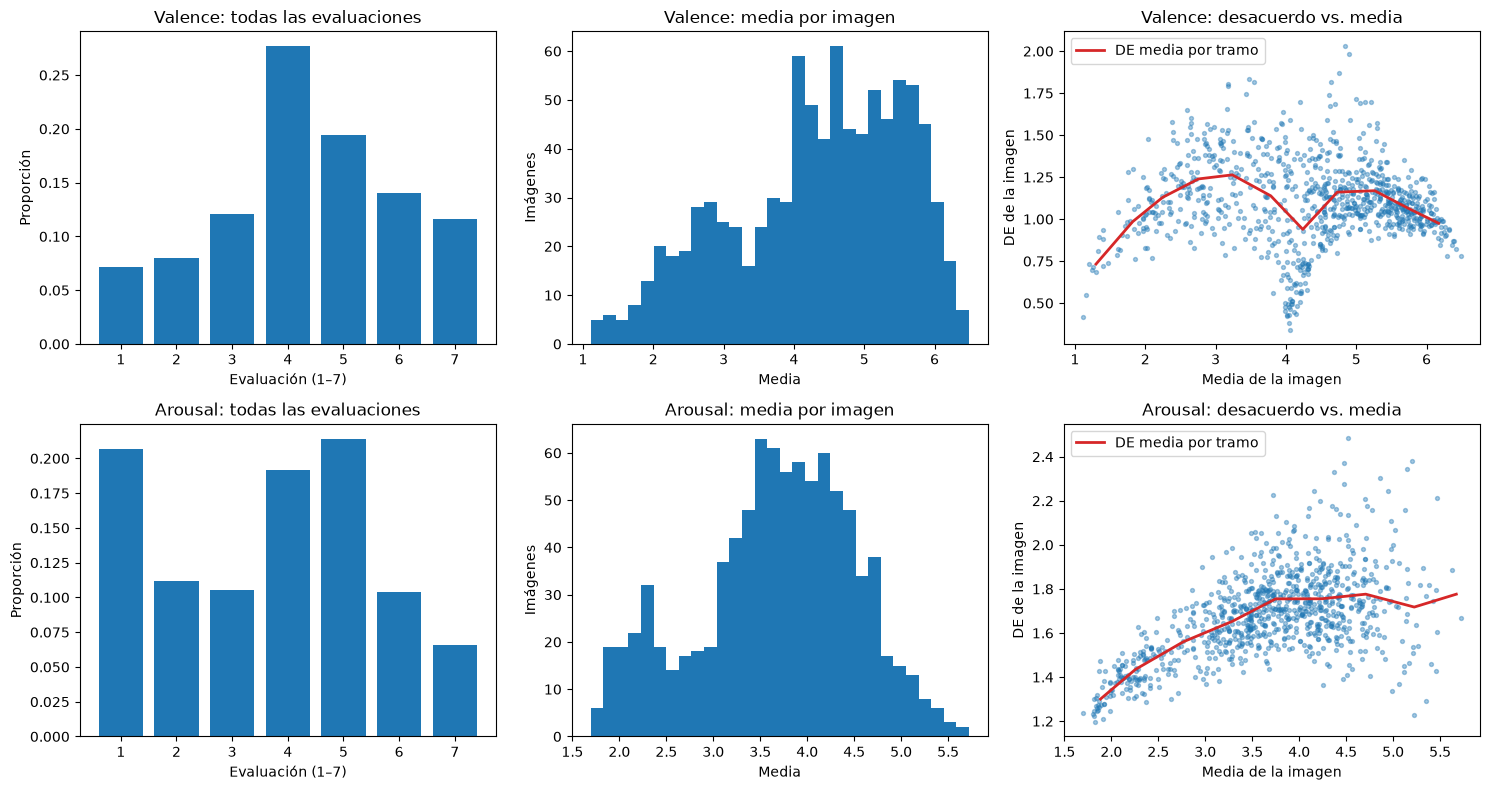

Valence: DE por imagen mediana 1.09 [P10 0.82, P90 1.42]
Arousal: DE por imagen mediana 1.68 [P10 1.42, P90 1.91]


In [6]:
stats_img = {d: pd.DataFrame({'mean': R[d].mean(), 'sd': R[d].std(), 'n': R[d].notna().sum()})
             .join(norms.set_index('item')[['Theme', 'Category']]) for d in DIMS}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, d in zip(axes, DIMS):
    counts = long.loc[long['valar'] == d, 'rating'].value_counts().sort_index()
    row[0].bar(counts.index, counts.values / counts.sum(), color='tab:blue')
    row[0].set(title=f'{d}: todas las evaluaciones', xlabel='Evaluación (1–7)', ylabel='Proporción')
    row[1].hist(stats_img[d]['mean'], bins=30, color='tab:blue')
    row[1].set(title=f'{d}: media por imagen', xlabel='Media', ylabel='Imágenes')
    s = stats_img[d]
    row[2].scatter(s['mean'], s['sd'], s=8, alpha=0.4)
    bins = pd.cut(s['mean'], np.arange(1, 7.5, 0.5))
    trend = s.groupby(bins, observed=True)[['mean', 'sd']].mean()
    row[2].plot(trend['mean'], trend['sd'], color='tab:red', lw=2, label='DE media por tramo')
    row[2].set(title=f'{d}: desacuerdo vs. media', xlabel='Media de la imagen', ylabel='DE de la imagen')
    row[2].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'distribuciones.png'), dpi=200)
plt.show()

for d in DIMS:
    print(f"{d}: DE por imagen mediana {stats_img[d]['sd'].median():.2f} "
          f"[P10 {stats_img[d]['sd'].quantile(.1):.2f}, P90 {stats_img[d]['sd'].quantile(.9):.2f}]")

## 3. Confiabilidad: split-half, ICC y α de Krippendorff
- **Split-half (Spearman-Brown)**: se divide al azar a los evaluadores en dos mitades, se correlacionan los promedios por imagen de cada mitad y se corrige al tamaño completo. Es la confiabilidad de la **norma publicada**.
- **ICC(1)**: confiabilidad de **un** evaluador. **ICC(1,k)**: del promedio de k ≈ 100 evaluadores.
- **α de Krippendorff** intervalar (debe parecerse a ICC(1)) y ordinal. Como referencia habitual: α ≥ 0.80 es confiable, 0.67–0.80 sirve para conclusiones tentativas y menos de 0.67 es bajo.

In [7]:
def split_half(M, n_splits=N_BOOT, seed=0):
    # Correlación entre promedios de dos mitades aleatorias de evaluadores, con Spearman-Brown
    g = np.random.default_rng(seed)
    X = M.to_numpy(dtype=float)
    out = []
    for _ in range(n_splits):
        half = g.permutation(len(X)) < len(X) // 2
        r = np.corrcoef(np.nanmean(X[half], 0), np.nanmean(X[~half], 0))[0, 1]
        out.append(2 * r / (1 + r))
    return np.array(out)


def icc_oneway(M):
    # ICC(1) e ICC(1,k) de un factor, con número distinto de evaluadores por imagen
    X = M.to_numpy(dtype=float)
    n_i = (~np.isnan(X)).sum(0)
    keep = n_i >= 2
    X, n_i = X[:, keep], n_i[keep]
    k, N = X.shape[1], n_i.sum()
    means = np.nanmean(X, 0)
    grand = np.nansum(X) / N
    msb = (n_i * (means - grand) ** 2).sum() / (k - 1)
    msw = np.nansum((X - means) ** 2) / (N - k)
    n0 = (N - (n_i ** 2).sum() / N) / (k - 1)
    return {'ICC1': (msb - msw) / (msb + (n0 - 1) * msw), 'ICC1k': (msb - msw) / msb, 'k': n0}


def value_counts_per_item(M, levels):
    # Matriz imágenes × categorías con el número de evaluadores que eligió cada valor
    X = M.to_numpy(dtype=float)
    return np.stack([(X == v).sum(0) for v in levels], 1)


def kripp_alpha(counts, metric, values=None):
    # α de Krippendorff a partir de la matriz de coincidencias (admite n distinto por imagen)
    counts = counts[counts.sum(1) >= 2]
    m = counts.sum(1, keepdims=True)
    w = counts / (m - 1)
    o = w.T @ counts - np.diag(w.sum(0))
    n_c = o.sum(1)
    n = n_c.sum()
    C = len(n_c)
    if metric == 'nominal':
        delta = 1.0 - np.eye(C)
    elif metric == 'interval':
        v = np.arange(C) if values is None else np.asarray(values, dtype=float)
        delta = (v[:, None] - v[None, :]) ** 2
    elif metric == 'ordinal':
        cum = np.concatenate([[0], np.cumsum(n_c)])
        lo, hi = np.minimum.outer(range(C), range(C)), np.maximum.outer(range(C), range(C))
        delta = (cum[hi + 1] - cum[lo] - (n_c[lo] + n_c[hi]) / 2) ** 2
    else:
        raise ValueError(metric)
    return 1 - (n - 1) * (o * delta).sum() / (np.outer(n_c, n_c) * delta).sum()


def boot_ci(counts, fn, n_boot=N_BOOT, seed=0):
    g = np.random.default_rng(seed)
    vals = [fn(counts[g.integers(0, len(counts), len(counts))]) for _ in range(n_boot)]
    return np.percentile(vals, [2.5, 97.5])


rows = []
for d in DIMS:
    sh = split_half(R[d])
    icc = icc_oneway(R[d])
    cnt = value_counts_per_item(R[d], LEVELS)
    row = {'dimension': d, 'split_half_SB': sh.mean(),
           'split_half_ci95': f'[{np.percentile(sh, 2.5):.3f}, {np.percentile(sh, 97.5):.3f}]',
           'ICC1 (1 evaluador)': icc['ICC1'], 'ICC1k (promedio)': icc['ICC1k'], 'k': icc['k']}
    for metric in ('interval', 'ordinal'):
        f = lambda c, metric=metric: kripp_alpha(c, metric, LEVELS)
        lo, hi = boot_ci(cnt, f)
        row[f'alpha_{metric}'] = f(cnt)
        row[f'alpha_{metric}_ci95'] = f'[{lo:.3f}, {hi:.3f}]'
    rows.append(row)
reliability = pd.DataFrame(rows)
reliability.to_csv(os.path.join(OUT, 'confiabilidad.csv'), index=False)
reliability

,dimension,split_half_SB,split_half_ci95,ICC1 (1 evaluador),ICC1k (promedio),k,alpha_interval,alpha_interval_ci95,alpha_ordinal,alpha_ordinal_ci95
0,Valence,0.992,"[0.990, 0.994]",0.539,0.992,103.249,0.538,"[0.515, 0.558]",0.534,"[0.509, 0.555]"
1,Arousal,0.963,"[0.944, 0.975]",0.191,0.960,102.239,0.191,"[0.177, 0.206]",0.194,"[0.181, 0.209]"


## 4. Un evaluador frente al consenso de los demás
Para cada persona se correlacionan sus 225 evaluaciones con el promedio de **los demás** evaluadores de esas mismas imágenes (*leave-one-out*). Esto indica cuánto se parece una sola anotación a la norma colectiva.

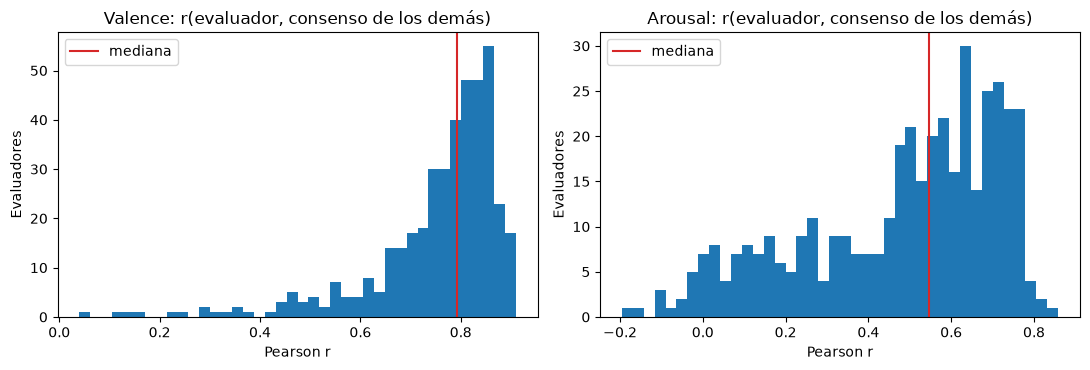

dimension  Arousal  Valence
r   count  409.000  413.000
    mean     0.481    0.752
    std      0.238    0.137
    min     -0.195    0.040
    10%      0.103    0.577
    50%      0.545    0.793
    90%      0.741    0.864
    max      0.858    0.910
mae count  409.000  413.000
    mean     1.420    0.881
    std      0.411    0.227
    min      0.570    0.505
    10%      0.969    0.641
    50%      1.362    0.838
    90%      2.041    1.174
    max      2.672    1.973

In [8]:
loo = []
for d in DIMS:
    X = R[d].to_numpy(dtype=float)
    S, N = np.nansum(X, 0), (~np.isnan(X)).sum(0)
    for pid, x, gender in zip(R[d].index, X, raw.set_index('ID').loc[R[d].index, 'Gender']):
        ok = ~np.isnan(x)
        others = (S[ok] - x[ok]) / (N[ok] - 1)
        loo.append({'dimension': d, 'ID': pid, 'Gender': gender,
                    'r': np.corrcoef(x[ok], others)[0, 1] if x[ok].std() > 0 else np.nan,
                    'mae': np.abs(x[ok] - others).mean()})
loo = pd.DataFrame(loo)
loo.to_csv(os.path.join(OUT, 'evaluador_vs_consenso.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, d in zip(axes, DIMS):
    ax.hist(loo.loc[loo.dimension == d, 'r'].dropna(), bins=40, color='tab:blue')
    ax.axvline(loo.loc[loo.dimension == d, 'r'].median(), color='tab:red', label='mediana')
    ax.set(title=f'{d}: r(evaluador, consenso de los demás)', xlabel='Pearson r', ylabel='Evaluadores')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'evaluador_vs_consenso.png'), dpi=200)
plt.show()
loo.groupby('dimension')[['r', 'mae']].describe(percentiles=[.1, .5, .9]).T

## 5. Valencia en 3 clases: el puente con el clasificador de anuncios
Cada evaluación se discretiza como **1–3 → Negative, 4 → Neutral, 5–7 → Positive** (4 es el punto neutral de la escala). La **etiqueta de consenso** de una imagen es la clase más votada; los empates se resuelven con la clase de la media (<3.5, 3.5–4.5, >4.5).

Se calcula:
- α de Krippendorff nominal y ordinal sobre las 3 clases.
- El **% de evaluadores que coincide con la clase de consenso** en cada imagen.
- **Un anotador vs. el consenso de los demás**: accuracy, macro-F1 y κ de Cohen. Si un dataset se etiqueta con **una sola persona por imagen**, un modelo que acierte *perfectamente* el consenso colectivo obtendría aproximadamente estos valores contra esas etiquetas. Es una estimación del **techo** alcanzable.

In [9]:
to_class = lambda v: np.digitize(v, [3.5, 4.5])      # 0 Negative, 1 Neutral, 2 Positive
V = R['Valence'].to_numpy(dtype=float)
cls_counts = np.stack([((~np.isnan(V)) & (to_class(V) == c)).sum(0) for c in range(3)], 1)
vmean = np.nanmean(V, 0)


def plurality(counts, mean):
    # Clase más votada; empates → clase de la media
    top = counts == counts.max(1, keepdims=True)
    tie = top.sum(1) > 1
    out = counts.argmax(1)
    out[tie] = to_class(mean[tie])
    return out


consensus = plurality(cls_counts, vmean)
agree = cls_counts[np.arange(len(consensus)), consensus] / cls_counts.sum(1)
val3 = pd.DataFrame({'item': ITEMS, 'consensus': np.array(CLASSES)[consensus], 'agreement': agree,
                     'mean': vmean, 'sd': np.nanstd(V, 0, ddof=1)}).merge(
    norms[['item', 'Theme', 'Category']], on='item')
val3.to_csv(os.path.join(OUT, 'valencia_3_clases_por_imagen.csv'), index=False)

alphas = {}
for metric in ('nominal', 'ordinal'):
    f = lambda c, metric=metric: kripp_alpha(c, metric)
    alphas[metric] = (f(cls_counts), *boot_ci(cls_counts, f))
print('Distribución de evaluaciones individuales:',
      dict(zip(CLASSES, (cls_counts.sum(0) / cls_counts.sum()).round(3))))
print('Distribución de clases de consenso:', val3['consensus'].value_counts().to_dict())
for metric, (a, lo, hi) in alphas.items():
    print(f'α de Krippendorff {metric} (3 clases): {a:.3f} [{lo:.3f}, {hi:.3f}]')
val3.groupby('consensus')['agreement'].describe()

Distribución de evaluaciones individuales: {'Negative': np.float64(0.272), 'Neutral': np.float64(0.277), 'Positive': np.float64(0.452)}
Distribución de clases de consenso: {'Positive': 464, 'Negative': 261, 'Neutral': 175}
α de Krippendorff nominal (3 clases): 0.376 [0.357, 0.392]
α de Krippendorff ordinal (3 clases): 0.507 [0.483, 0.528]


,count,mean,std,min,25%,50%,75%,max
consensus,,,,,,,,
Negative,261.000,0.724,0.175,0.356,0.588,0.735,0.881,0.991
Neutral,175.000,0.628,0.154,0.347,0.493,0.598,0.765,0.912
Positive,464.000,0.730,0.159,0.343,0.606,0.755,0.871,0.980


,valor,ci95_low,ci95_high
accuracy,0.703,0.690,0.714
macro_f1,0.676,0.662,0.687
kappa,0.532,0.510,0.549
f1_Negative,0.748,0.726,0.767
f1_Neutral,0.507,0.471,0.535
f1_Positive,0.773,0.758,0.788


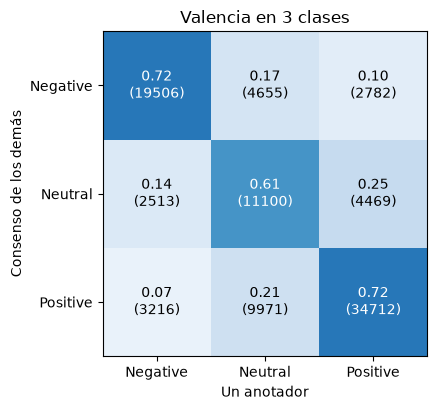

In [10]:
# Un anotador vs. consenso de los demás (leave-one-out), todas las evaluaciones de valencia
rater_idx, item_idx = np.where(~np.isnan(V))
own = to_class(V[rater_idx, item_idx])
loo_counts = cls_counts[item_idx] - np.eye(3, dtype=int)[own]
n_other = loo_counts.sum(1)
loo_mean = (np.nansum(V, 0)[item_idx] - V[rater_idx, item_idx]) / n_other
loo_cons = plurality(loo_counts, loo_mean)


def agreement_metrics(y_true, y_pred):
    f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
    return {'accuracy': (y_true == y_pred).mean(),
            'macro_f1': f1.mean(), 'kappa': cohen_kappa_score(y_true, y_pred),
            **{f'f1_{c}': v for c, v in zip(CLASSES, f1)}}


single = agreement_metrics(loo_cons, own)
# IC95% bootstrap sobre imágenes
rows_of_item = [np.flatnonzero(item_idx == i) for i in range(len(ITEMS))]
boot = []
for _ in range(200):
    pick = rng.integers(0, len(ITEMS), len(ITEMS))
    mask = np.concatenate([rows_of_item[i] for i in pick])
    boot.append(agreement_metrics(loo_cons[mask], own[mask]))
boot = pd.DataFrame(boot)
ceiling = pd.DataFrame({'valor': single, 'ci95_low': boot.quantile(.025), 'ci95_high': boot.quantile(.975)})
ceiling.to_csv(os.path.join(OUT, 'techo_un_anotador.csv'))
display(ceiling)

cm = confusion_matrix(loo_cons, own, labels=[0, 1, 2])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cmn[i, j]:.2f}\n({cm[i, j]})', ha='center', va='center',
                color='white' if cmn[i, j] > .5 else 'black')
ax.set_xticks(range(3), CLASSES)
ax.set_yticks(range(3), CLASSES)
ax.set(xlabel='Un anotador', ylabel='Consenso de los demás', title='Valencia en 3 clases')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'confusion_anotador_vs_consenso.png'), dpi=200)
plt.show()

### ¿Cuántos anotadores por imagen hacen falta?
Se simula etiquetar cada imagen con la clase más votada por **r** evaluadores tomados al azar y se compara con el consenso de **los evaluadores restantes**. Esto muestra cuánto mejoraría la calidad de las etiquetas de un dataset (y por tanto el techo de cualquier modelo) al usar más anotadores por imagen.

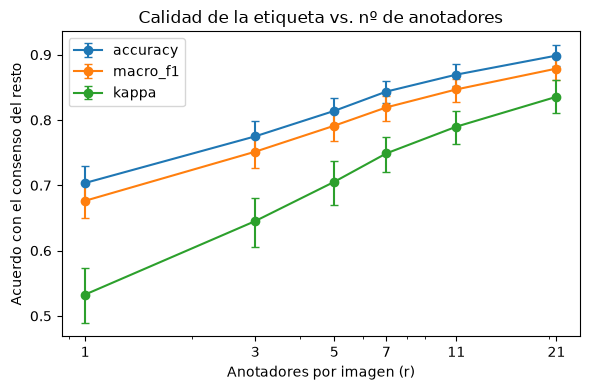

,accuracy,macro_f1,kappa,f1_Negative,f1_Neutral,f1_Positive
r,,,,,,
1,0.704,0.676,0.533,0.751,0.506,0.772
3,0.775,0.751,0.645,0.824,0.594,0.836
5,0.814,0.791,0.705,0.862,0.643,0.869
7,0.844,0.819,0.749,0.882,0.686,0.890
11,0.870,0.847,0.790,0.908,0.723,0.910
21,0.899,0.879,0.836,0.931,0.776,0.929


In [11]:
R_VALUES = [1, 3, 5, 7, 11, 21]
N_SIM = 100
votes = [to_class(V[~np.isnan(V[:, j]), j]) for j in range(V.shape[1])]
raw_vals = [V[~np.isnan(V[:, j]), j] for j in range(V.shape[1])]
sim_rows = []
for r in R_VALUES:
    for s in range(N_SIM):
        y_ref, y_lab = [], []
        for v, x in zip(votes, raw_vals):
            p = rng.permutation(len(v))
            a, b = p[:r], p[r:]
            ca = np.bincount(v[a], minlength=3)[None]
            cb = np.bincount(v[b], minlength=3)[None]
            y_lab.append(plurality(ca, np.array([x[a].mean()]))[0])
            y_ref.append(plurality(cb, np.array([x[b].mean()]))[0])
        sim_rows.append({'r': r, 'sim': s, **agreement_metrics(np.array(y_ref), np.array(y_lab))})
sim = pd.DataFrame(sim_rows)
sim.to_csv(os.path.join(OUT, 'simulacion_n_anotadores.csv'), index=False)
sim_summary = sim.groupby('r')[['accuracy', 'macro_f1', 'kappa', 'f1_Negative', 'f1_Neutral', 'f1_Positive']].mean()

fig, ax = plt.subplots(figsize=(6, 4))
for col in ('accuracy', 'macro_f1', 'kappa'):
    g = sim.groupby('r')[col]
    ax.errorbar(R_VALUES, g.mean(), yerr=[g.mean() - g.quantile(.025), g.quantile(.975) - g.mean()],
                marker='o', capsize=3, label=col)
ax.set(xscale='log', xticks=R_VALUES, xticklabels=R_VALUES, xlabel='Anotadores por imagen (r)',
       ylabel='Acuerdo con el consenso del resto', title='Calidad de la etiqueta vs. nº de anotadores')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'n_anotadores.png'), dpi=200)
plt.show()
sim_summary

## 5b. Clasificación de cada imagen en 3 categorías
- **Valencia → Negative / Neutral / Positive.**
- **Arousal → Low / Medium / High.** El arousal mide intensidad, no agrado: una escena de guerra y una fiesta tienen ambas arousal alto. Por eso no se lleva a positivo/negativo.

Se usan los mismos cortes en ambas dimensiones (1–3, 4, 5–7) y dos criterios por imagen:
- `class_mean`: clase de la **media** de la imagen (<3.5, 3.5–4.5, >4.5).
- `class_vote`: clase **más votada** al discretizar cada evaluación (empates → clase de la media).

También se guarda el % de votos de cada clase, para filtrar después las imágenes con poco consenso. El resultado queda en `resultados/oasis/oasis_clases_por_imagen.csv`.

In [12]:
SCALES = {'Valence': CLASSES, 'Arousal': ['Low', 'Medium', 'High']}


def three_class_counts(M):
    X = M.to_numpy(dtype=float)
    counts = np.stack([((~np.isnan(X)) & (to_class(X) == c)).sum(0) for c in range(3)], 1)
    return counts, np.nanmean(X, 0)


def single_annotator_vs_rest(M, names):
    # Un evaluador vs. la clase más votada por los demás evaluadores de la misma imagen
    X = M.to_numpy(dtype=float)
    counts, _ = three_class_counts(M)
    r_idx, i_idx = np.where(~np.isnan(X))
    own = to_class(X[r_idx, i_idx])
    rest = counts[i_idx] - np.eye(3, dtype=int)[own]
    rest_mean = (np.nansum(X, 0)[i_idx] - X[r_idx, i_idx]) / rest.sum(1)
    ref = plurality(rest, rest_mean)
    f1 = f1_score(ref, own, labels=[0, 1, 2], average=None, zero_division=0)
    return {'accuracy': (ref == own).mean(), 'macro_f1': f1.mean(),
            'kappa': cohen_kappa_score(ref, own), **{f'f1_{n}': v for n, v in zip(names, f1)}}


per_image = norms.set_index('item').loc[ITEMS, ['Theme', 'Category']].reset_index()
agreement_rows = []
for d, names in SCALES.items():
    counts, mean = three_class_counts(R[d])
    vote = plurality(counts, mean)
    per_image[f'{d}_mean'] = mean
    per_image[f'{d}_sd'] = R[d].std().to_numpy()
    per_image[f'{d}_class_mean'] = np.array(names)[to_class(mean)]
    per_image[f'{d}_class_vote'] = np.array(names)[vote]
    for c, n in enumerate(names):
        per_image[f'{d}_pct_{n}'] = counts[:, c] / counts.sum(1)
    per_image[f'{d}_agreement'] = counts[np.arange(len(vote)), vote] / counts.sum(1)
    agreement_rows.append({
        'dimension': d, 'classes': ' / '.join(names),
        'alpha_nominal': kripp_alpha(counts, 'nominal'), 'alpha_ordinal': kripp_alpha(counts, 'ordinal'),
        'agreement_mean': per_image[f'{d}_agreement'].mean(),
        'class_mean_eq_vote': (per_image[f'{d}_class_mean'] == per_image[f'{d}_class_vote']).mean(),
        **{f'1_anotador_{k}': v for k, v in single_annotator_vs_rest(R[d], names).items()
           if not k.startswith('f1_')}})
per_image.to_csv(os.path.join(OUT, 'oasis_clases_por_imagen.csv'), index=False)

print('Número de imágenes por clase (criterio: más votada)')
display(pd.concat({d: per_image[f'{d}_class_vote'].value_counts().reindex(n) for d, n in SCALES.items()}, axis=1))
print('Acuerdo entre evaluadores en 3 categorías')
display(pd.DataFrame(agreement_rows).set_index('dimension').T)
print('Valencia × arousal (imágenes, criterio: más votada)')
display(pd.crosstab(per_image['Valence_class_vote'], per_image['Arousal_class_vote'])
        .reindex(index=SCALES['Valence'], columns=SCALES['Arousal']))
per_image.head()

Número de imágenes por clase (criterio: más votada)


,Valence,Arousal
Negative,261.000,NaN
Neutral,175.000,NaN
Positive,464.000,NaN
Low,NaN,451.000
Medium,NaN,9.000
High,NaN,440.000


Acuerdo entre evaluadores en 3 categorías


dimension,Valence,Arousal
classes,Negative / Neutral / Positive,Low / Medium / High
alpha_nominal,0.376,0.110
alpha_ordinal,0.507,0.166
agreement_mean,0.708,0.557
class_mean_eq_vote,0.883,0.551
1_anotador_accuracy,0.703,0.551
1_anotador_macro_f1,0.676,0.413
1_anotador_kappa,0.532,0.249


Valencia × arousal (imágenes, criterio: más votada)


Arousal_class_vote,Low,Medium,High
Valence_class_vote,,,
Negative,79,4,178
Neutral,170,0,5
Positive,202,5,257


,item,Theme,Category,Valence_mean,Valence_sd,Valence_class_mean,Valence_class_vote,Valence_pct_Negative,Valence_pct_Neutral,Valence_pct_Positive,Valence_agreement,Arousal_mean,Arousal_sd,Arousal_class_mean,Arousal_class_vote,Arousal_pct_Low,Arousal_pct_Medium,Arousal_pct_High,Arousal_agreement
0,I1,Acorns 1,Object,4.686,0.954,Positive,Neutral,0.020,0.539,0.441,0.539,2.347,1.603,Low,Low,0.713,0.188,0.099,0.713
1,I2,Acorns 2,Object,4.520,0.841,Positive,Neutral,0.010,0.637,0.353,0.637,2.228,1.399,Low,Low,0.733,0.208,0.059,0.733
2,I3,Acorns 3,Object,4.755,0.959,Positive,Positive,0.020,0.490,0.490,0.490,2.307,1.515,Low,Low,0.713,0.208,0.079,0.713
3,I4,Alcohol 1,Object,4.685,1.189,Positive,Positive,0.102,0.352,0.546,0.546,2.865,1.696,Low,Low,0.567,0.240,0.192,0.567
4,I5,Alcohol 2,Object,4.250,1.137,Neutral,Neutral,0.194,0.481,0.324,0.481,3.000,1.701,Low,Low,0.567,0.192,0.240,0.567


## 6. Acuerdo por categoría de imagen

In [13]:
cat_rows = []
cat_of = norms.set_index('item').loc[ITEMS, 'Category'].to_numpy()
for d in DIMS:
    cnt = value_counts_per_item(R[d], LEVELS)
    for cat in sorted(set(cat_of)):
        sel = cat_of == cat
        f = lambda c: kripp_alpha(c, 'interval', LEVELS)
        lo, hi = boot_ci(cnt[sel], f)
        cat_rows.append({'dimension': d, 'category': cat, 'n_images': sel.sum(),
                         'alpha_interval': f(cnt[sel]), 'ci95': f'[{lo:.3f}, {hi:.3f}]',
                         'sd_median': stats_img[d].loc[np.array(ITEMS)[sel], 'sd'].median()})
for cat in sorted(set(cat_of)):
    sel = cat_of == cat
    f = lambda c: kripp_alpha(c, 'nominal')
    lo, hi = boot_ci(cls_counts[sel], f)
    cat_rows.append({'dimension': 'Valence (3 clases)', 'category': cat, 'n_images': sel.sum(),
                     'alpha_nominal': f(cls_counts[sel]), 'ci95': f'[{lo:.3f}, {hi:.3f}]',
                     'agreement_mean': val3.loc[sel, 'agreement'].mean()})
by_cat = pd.DataFrame(cat_rows)
by_cat.to_csv(os.path.join(OUT, 'acuerdo_por_categoria.csv'), index=False)
by_cat

,dimension,category,n_images,alpha_interval,ci95,sd_median,alpha_nominal,agreement_mean
0,Valence,Animal,134,0.507,"[0.451, 0.555]",1.191,NaN,NaN
1,Valence,Object,200,0.491,"[0.441, 0.538]",0.993,NaN,NaN
2,Valence,Person,346,0.510,"[0.469, 0.545]",1.107,NaN,NaN
3,Valence,Scene,220,0.613,"[0.577, 0.647]",1.106,NaN,NaN
4,Arousal,Animal,134,0.084,"[0.061, 0.108]",1.688,NaN,NaN
5,Arousal,Object,200,0.193,"[0.170, 0.214]",1.543,NaN,NaN
6,Arousal,Person,346,0.127,"[0.111, 0.145]",1.670,NaN,NaN
7,Arousal,Scene,220,0.158,"[0.132, 0.181]",1.747,NaN,NaN
8,Valence (3 clases),Animal,134,NaN,"[0.276, 0.361]",NaN,0.319,0.699
9,Valence (3 clases),Object,200,NaN,"[0.328, 0.402]",NaN,0.365,0.716


## 7. Hombres vs. mujeres
Correlación entre los promedios por imagen calculados por separado para hombres y mujeres (como en el artículo original), diferencia media pareada y α intervalar dentro de cada grupo.

In [14]:
g_rows = []
for d in DIMS:
    gender = raw.set_index('ID').loc[R[d].index, 'Gender']
    m = R[d][gender == 'Male'].mean()
    f = R[d][gender == 'Female'].mean()
    row = {'dimension': d, 'r_means_men_women': np.corrcoef(m, f)[0, 1],
           'mean_diff_women_minus_men': (f - m).mean(),
           'wilcoxon_p': stats.wilcoxon(f - m).pvalue}
    for g in ('Male', 'Female'):
        row[f'alpha_interval_{g}'] = kripp_alpha(value_counts_per_item(R[d][gender == g], LEVELS),
                                                 'interval', LEVELS)
    g_rows.append(row)
by_gender = pd.DataFrame(g_rows)
by_gender.to_csv(os.path.join(OUT, 'acuerdo_por_genero.csv'), index=False)
by_gender

,dimension,r_means_men_women,mean_diff_women_minus_men,wilcoxon_p,alpha_interval_Male,alpha_interval_Female
0,Valence,0.951,-0.008,0.345,0.507,0.586
1,Arousal,0.826,0.122,0.000,0.199,0.206


## 8. Imágenes y temas con mayor y menor consenso en valencia
OASIS incluye desnudos y contenido sexual explícito, y varias de esas imágenes están entre las de mayor desacuerdo. Por eso las imágenes **no se muestran por defecto**: se listan los temas en una tabla. Para verlas, cambie `SHOW_IMAGES = True` (no se guardan en disco).


In [15]:
SHOW_IMAGES = False

val3['theme_group'] = val3['Theme'].str.replace(r'\s*\d+$', '', regex=True)
themes = (val3.groupby(['theme_group', 'Category'])
          .agg(n_images=('item', 'size'), mean_valence=('mean', 'mean'), sd_mean=('sd', 'mean'),
               agreement_mean=('agreement', 'mean'))
          .reset_index())
themes.to_csv(os.path.join(OUT, 'acuerdo_por_tema.csv'), index=False)
cols = ['Theme', 'Category', 'mean', 'sd', 'consensus', 'agreement']
print('Imágenes con mayor desacuerdo (DE de la valencia)')
display(val3.nlargest(10, 'sd')[cols])
print('Imágenes con mayor consenso (clase de valencia)')
display(val3.nlargest(10, 'agreement')[cols])
print('Temas con mayor desacuerdo (≥3 imágenes)')
display(themes[themes.n_images >= 3].nlargest(10, 'sd_mean'))


def show(items, title):
    fig, axes = plt.subplots(1, len(items), figsize=(3.2 * len(items), 3.4))
    for ax, (_, r) in zip(axes, items.iterrows()):
        path = os.path.join(IMG_DIR, f"{r['Theme']}.jpg")
        if os.path.exists(path):
            ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(f"{r['Theme']}\nmedia {r['mean']:.2f} ± {r['sd']:.2f}\n"
                     f"{r['consensus']} ({100 * r['agreement']:.0f}% de acuerdo)", fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


if SHOW_IMAGES:
    show(val3.nlargest(6, 'agreement'), 'Mayor consenso (clase de valencia)')
    show(val3.nlargest(6, 'sd'), 'Mayor desacuerdo (DE de la valencia)')


Imágenes con mayor desacuerdo (DE de la valencia)


,Theme,Category,mean,sd,consensus,agreement
539,Nude couple 14,Person,4.842,2.033,Positive,0.673
582,Nude woman 20,Person,4.892,1.985,Positive,0.578
584,Nude woman 22,Person,4.750,1.870,Positive,0.509
558,Nude man 20,Person,3.481,1.837,Negative,0.444
536,Nude couple 11,Person,4.647,1.817,Positive,0.618
560,Nude man 21,Person,3.549,1.816,Negative,0.402
549,Nude man 11,Person,3.176,1.804,Negative,0.539
869,War 7,Person,3.178,1.791,Negative,0.505
264,Dog 15,Animal,3.431,1.744,Negative,0.529
565,Nude woman 3,Person,4.618,1.741,Positive,0.559


Imágenes con mayor consenso (clase de valencia)


,Theme,Category,mean,sd,consensus,agreement
437,Injury 2,Person,2.093,0.768,Negative,0.991
119,Car crash 1,Scene,1.853,0.763,Negative,0.990
495,Miserable pose 3,Person,1.108,0.420,Negative,0.990
854,Tumor 1,Person,1.402,0.721,Negative,0.990
286,Dummy 1,Object,1.157,0.550,Negative,0.981
255,Dog 6,Animal,6.490,0.780,Positive,0.980
451,KKK rally 2,Person,1.255,0.713,Negative,0.980
208,Dead bodies 2,Person,1.248,0.699,Negative,0.980
261,Dog 12,Animal,6.287,0.779,Positive,0.980
615,Penguins 2,Animal,6.208,0.875,Positive,0.980


Temas con mayor desacuerdo (≥3 imágenes)


,theme_group,Category,n_images,mean_valence,sd_mean,agreement_mean
8,BDSM,Person,3,4.073,1.564,0.428
153,Nude woman,Person,22,4.967,1.545,0.613
111,Gun,Object,9,2.868,1.500,0.676
85,Explosion,Scene,6,2.375,1.439,0.792
229,Soldiers,Scene,3,3.809,1.431,0.564
253,Volcano,Scene,3,3.593,1.426,0.526
137,Memorial,Scene,3,3.561,1.424,0.620
255,War,Person,5,2.553,1.377,0.719
134,Lion,Animal,5,4.395,1.365,0.587
223,Snake,Animal,6,2.895,1.362,0.654


## 9. Resumen

In [16]:
v = reliability.set_index('dimension')
summary = pd.Series({
    'Valencia: confiabilidad del promedio (split-half SB)': v.loc['Valence', 'split_half_SB'],
    'Valencia: confiabilidad de 1 evaluador (ICC1)': v.loc['Valence', 'ICC1 (1 evaluador)'],
    'Arousal: confiabilidad del promedio (split-half SB)': v.loc['Arousal', 'split_half_SB'],
    'Arousal: confiabilidad de 1 evaluador (ICC1)': v.loc['Arousal', 'ICC1 (1 evaluador)'],
    'Valencia 3 clases: α nominal': alphas['nominal'][0],
    'Valencia 3 clases: % medio de acuerdo con el consenso': val3['agreement'].mean(),
    'Techo con 1 anotador: accuracy': single['accuracy'],
    'Techo con 1 anotador: macro-F1': single['macro_f1'],
    'Techo con 1 anotador: κ de Cohen': single['kappa'],
    'Macro-F1 con 5 anotadores': sim_summary.loc[5, 'macro_f1'],
}, name='valor')
summary.to_csv(os.path.join(OUT, 'resumen.csv'))
summary.to_frame()

,valor
Valencia: confiabilidad del promedio (split-half SB),0.992
Valencia: confiabilidad de 1 evaluador (ICC1),0.539
Arousal: confiabilidad del promedio (split-half SB),0.963
Arousal: confiabilidad de 1 evaluador (ICC1),0.191
Valencia 3 clases: α nominal,0.376
Valencia 3 clases: % medio de acuerdo con el consenso,0.708
Techo con 1 anotador: accuracy,0.703
Techo con 1 anotador: macro-F1,0.676
Techo con 1 anotador: κ de Cohen,0.532
Macro-F1 con 5 anotadores,0.791


### Cómo leer estos resultados
- **Promedio muy confiable y evaluador individual poco confiable** es lo habitual en normas afectivas: el consenso de ~100 personas es estable, pero cada persona por separado discrepa bastante. La valencia suele tener más acuerdo que el arousal.
- **El techo con un anotador** es la referencia más útil para el clasificador de anuncios. Si los anuncios fueron etiquetados por una sola persona, ni siquiera un modelo que reprodujera perfectamente el juicio colectivo superaría aproximadamente ese macro-F1 contra esas etiquetas. Conviene compararlo con el ~0.5 de CLIP.
- **Precaución al trasladarlo**: OASIS son fotografías naturales evaluadas en una escala continua por participantes de EE. UU.; los anuncios tienen texto, marca y otro contexto cultural, y sus etiquetas venían de emociones discretas agrupadas en valencia. Es un **punto de referencia**, no una medida directa del acuerdo en el dataset de anuncios.